# 🔍 One-Class SVM — Kredi Kartı Dolandırıcılığı Tespiti

**One-Class SVM**, yalnızca **normal (pozitif) veriyle** eğitilen bir anomali tespit algoritmasıdır.
Test sırasında, modelin öğrendiği "normal" bölgenin **dışına** düşen noktalar **anormal (outlier)** olarak işaretlenir.

---

### 📌 Veri Seti

**Credit Card Fraud Detection** (Kaggle) — Avrupalı kart sahiplerinin 2013 yılındaki işlemleri.
- 284.807 işlem, sadece 492 tanesi dolandırıcılık (%0.17)
- Özellikler `V1..V28` PCA ile dönüştürülmüş (gizlilik nedeniyle), `Amount` işlem tutarı
- `Class`: 0 = normal işlem, 1 = dolandırıcılık

> `creditcard.csv` dosyasını `../data/` klasörüne yerleştirin (bkz. `data/README.md`): https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

> ⚠️ **Not:** One-Class SVM'in eğitim maliyeti veri boyutuyla ikinci/üçüncü dereceden artar.
> Bu yüzden 284.807 satırın tamamı yerine **dengeli bir örneklem** üzerinde çalışacağız.


## 📦 1. Kütüphanelerin İçe Aktarılması

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("✅ Tüm kütüphaneler başarıyla yüklendi.")

✅ Tüm kütüphaneler başarıyla yüklendi.


## 🗂️ 2. Veri Setinin Yüklenmesi

Gerçek dünya senaryosu: **kredi kartı işlem kayıtları**
- Eğitim verisi → yalnızca **normal** işlemler
- Test verisi → normal + dolandırıcılık işlemleri

In [2]:
df = pd.read_csv("../data/creditcard.csv")

print(f"Veri seti boyutu : {df.shape}")
print(f"\nSınıf dağılımı:")
print(df["Class"].value_counts())
print(f"\nDolandırıcılık oranı : %{df['Class'].mean()*100:.3f}")

df.head()

Veri seti boyutu : (284807, 31)

Sınıf dağılımı:
Class
0    284315
1       492
Name: count, dtype: int64

Dolandırıcılık oranı : %0.173


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## ✂️ 3. Örnekleme ve Eğitim / Test Ayrımı

One-Class SVM'in hesaplama maliyeti nedeniyle normal işlemlerden **4.000 örneklik** bir alt küme alıyoruz.
Dolandırıcılık işlemlerinin tamamı (492 kayıt) zaten az sayıda olduğundan **tümü** test setine dahil edilir.

In [3]:
np.random.seed(42)

normal = df[df["Class"] == 0]
fraud = df[df["Class"] == 1]

normal_sample = normal.sample(n=4000, random_state=42)

train_normal, test_normal = train_test_split(normal_sample, test_size=0.25, random_state=42)

test_df = pd.concat([test_normal, fraud])

features = [c for c in df.columns if c not in ["Time", "Class"]]

X_train = train_normal[features].values
X_test = test_df[features].values

y_test_true = np.where(test_df["Class"].values == 0, 1, -1)

print(f"Eğitim seti boyutu  : {X_train.shape}  → {X_train.shape[0]} normal işlem (örneklenmiş)")
print(f"Test  seti boyutu   : {X_test.shape}  → {len(test_normal)} normal + {len(fraud)} dolandırıcılık")

Eğitim seti boyutu  : (3000, 29)  → 3000 normal işlem (örneklenmiş)
Test  seti boyutu   : (1492, 29)  → 1000 normal + 492 dolandırıcılık


## ⚖️ 4. Özellik Ölçekleme (Feature Scaling)

SVM, özellikler arasındaki **ölçek farklılıklarına** çok duyarlıdır.
`StandardScaler`: her özelliği **ortalama=0, standart sapma=1** olacak şekilde dönüştürür.

> ⚠️ **Kritik Kural**: Scaler **yalnızca eğitim verisiyle** fit edilir.
> Test verisi aynı parametrelerle sadece **transform** edilir (data leakage önlenir).

In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Eğitim verisi — Ortalama: {X_train_scaled.mean(axis=0)[:5].round(4)}")
print(f"Eğitim verisi — Std Dev : {X_train_scaled.std(axis=0)[:5].round(4)}")
print("\n✅ Ölçekleme tamamlandı (ortalama≈0, std≈1 olmalı)")

Eğitim verisi — Ortalama: [-0.  0.  0. -0.  0.]
Eğitim verisi — Std Dev : [1. 1. 1. 1. 1.]

✅ Ölçekleme tamamlandı (ortalama≈0, std≈1 olmalı)


## 🤖 5. Model Tanımı ve Hiperparametreler

| Parametre | Açıklama | Örnek Değer |
|-----------|----------|---------|
| `kernel` | Veriyi yüksek boyuta taşıyan çekirdek fonksiyonu | `'rbf'` (en yaygın) |
| `nu` | **Beklenen anomali oranı** ve destek vektörü üst sınırı `(0,1]` | `0.05` |
| `gamma` | RBF çekirdeğinin genişliği; `'scale'` → `1/(n_features * X.var())` | `'scale'` |

In [5]:
model = OneClassSVM(
    kernel="rbf",
    nu=0.05,
    gamma="scale"
)

print("✅ Model oluşturuldu:")
print(model)

✅ Model oluşturuldu:
OneClassSVM(nu=0.05)


## 🏋️ 6. Modeli Eğitme

> One-Class SVM, **yalnızca normal veriden** öğrenir.
> Hedef etiket (`y`) **verilmez** → bu bir **unsupervised (gözetimsiz)** öğrenme adımıdır.

In [6]:
model.fit(X_train_scaled)

train_predictions = model.predict(X_train_scaled)

n_inliers_train = (train_predictions == 1).sum()
n_outliers_train = (train_predictions == -1).sum()

print(f"✅ Model eğitildi — {X_train_scaled.shape[0]} normal işlem kullanıldı")
print(f"\nEğitim verisi üzerindeki sonuçlar:")
print(f"  Normal  (+1): {n_inliers_train}")
print(f"  Anormal (-1): {n_outliers_train}  ← nu={model.nu} nedeniyle beklenen ≈ {int(len(X_train)*model.nu)} nokta")

✅ Model eğitildi — 3000 normal işlem kullanıldı

Eğitim verisi üzerindeki sonuçlar:
  Normal  (+1): 2832
  Anormal (-1): 168  ← nu=0.05 nedeniyle beklenen ≈ 150 nokta


## 🔮 7. Test Verisi Üzerinde Tahmin

In [7]:
y_pred = model.predict(X_test_scaled)

scores = model.decision_function(X_test_scaled)

correct_mask = (y_pred == y_test_true)
accuracy = correct_mask.mean() * 100

TP = ((y_pred == 1) & (y_test_true == 1)).sum()
TN = ((y_pred == -1) & (y_test_true == -1)).sum()
FP = ((y_pred == 1) & (y_test_true == -1)).sum()
FN = ((y_pred == -1) & (y_test_true == 1)).sum()

y_true_bin = (y_test_true == -1).astype(int)
auc = roc_auc_score(y_true_bin, -scores)

print("📊 TEST SONUÇLARI")
print("=" * 40)
print(f"Genel Doğruluk         : %{accuracy:.1f}")
print(f"ROC-AUC Skoru          : {auc:.4f}")
print()
print(f"Gerçek Pozitif  (TP)  : {TP:3d}  ✅ Normal,  doğru tahmin")
print(f"Gerçek Negatif  (TN)  : {TN:3d}  ✅ Dolandırıcılık, doğru tahmin")
print(f"Yanlış Pozitif  (FP)  : {FP:3d}  ❌ Dolandırıcılık, normal diye geçti")
print(f"Yanlış Negatif  (FN)  : {FN:3d}  ❌ Normal,  dolandırıcılık diye işaretlendi")
print()
print(f"Karar skoru — Min: {scores.min():.3f} | Maks: {scores.max():.3f} | Ort: {scores.mean():.3f}")

📊 TEST SONUÇLARI
Genel Doğruluk         : %91.8
ROC-AUC Skoru          : 0.9490

Gerçek Pozitif  (TP)  : 933  ✅ Normal,  doğru tahmin
Gerçek Negatif  (TN)  : 436  ✅ Dolandırıcılık, doğru tahmin
Yanlış Pozitif  (FP)  :  56  ❌ Dolandırıcılık, normal diye geçti
Yanlış Negatif  (FN)  :  67  ❌ Normal,  dolandırıcılık diye işaretlendi

Karar skoru — Min: -2.631 | Maks: 3.922 | Ort: 0.608


## 📊 8. PCA(2B) Uzayında Karar Sınırı Görselleştirmesi

30 boyutlu veriyi görebilmek için **PCA** ile 2 boyuta indirgiyoruz.
Karar sınırını görebilmek adına aynı mimaride ikinci bir One-Class SVM,
**yalnızca görselleştirme amacıyla** PCA(2B) verisi üzerinde ayrıca eğitilir.

/tmp/ipykernel_520/17736331.py:55: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_520/17736331.py:55: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_520/17736331.py:56: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("karar_siniri.png", dpi=150, bbox_inches="tight")
/tmp/ipykernel_520/17736331.py:56: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("karar_siniri.png", dpi=150, bbox_inches="tight")


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


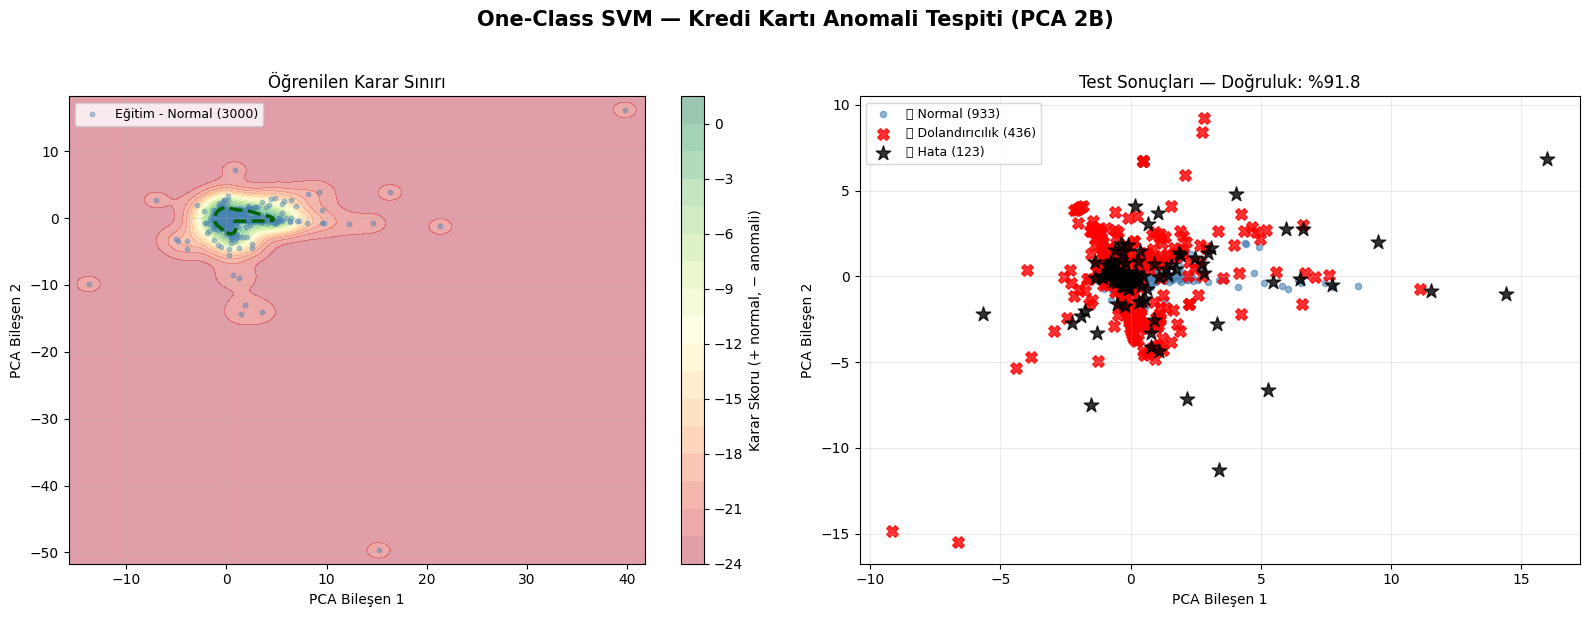

📸 karar_siniri.png kaydedildi


In [8]:
pca_viz = PCA(n_components=2, random_state=42)
X_train_pca = pca_viz.fit_transform(X_train_scaled)
X_test_pca = pca_viz.transform(X_test_scaled)

viz_model = OneClassSVM(kernel="rbf", nu=0.05, gamma="scale")
viz_model.fit(X_train_pca)

xx, yy = np.meshgrid(
    np.linspace(X_train_pca[:, 0].min() - 2, X_train_pca[:, 0].max() + 2, 300),
    np.linspace(X_train_pca[:, 1].min() - 2, X_train_pca[:, 1].max() + 2, 300)
)

grid_points = np.c_[xx.ravel(), yy.ravel()]

Z = viz_model.decision_function(grid_points)
Z = Z.reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("One-Class SVM — Kredi Kartı Anomali Tespiti (PCA 2B)", fontsize=15, fontweight="bold", y=1.02)

ax1 = axes[0]
cf = ax1.contourf(xx, yy, Z, levels=20, cmap="RdYlGn", alpha=0.4)
plt.colorbar(cf, ax=ax1, label="Karar Skoru (+ normal, − anomali)")

ax1.contour(xx, yy, Z, levels=[0], linewidths=2.5, colors="darkgreen", linestyles="--")

ax1.scatter(X_train_pca[:, 0], X_train_pca[:, 1],
            c="steelblue", s=10, alpha=0.4, label=f"Eğitim - Normal ({len(X_train_pca)})")

ax1.set_title("Öğrenilen Karar Sınırı")
ax1.set_xlabel("PCA Bileşen 1")
ax1.set_ylabel("PCA Bileşen 2")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.25)

ax2 = axes[1]
correct = y_pred == y_test_true
wrong = ~correct

mask = correct & (y_test_true == 1)
ax2.scatter(X_test_pca[mask, 0], X_test_pca[mask, 1],
            c="steelblue", s=20, alpha=0.6, label=f"✅ Normal ({mask.sum()})")
mask = correct & (y_test_true == -1)
ax2.scatter(X_test_pca[mask, 0], X_test_pca[mask, 1],
            c="red", marker="X", s=70, alpha=0.8, label=f"✅ Dolandırıcılık ({mask.sum()})")
ax2.scatter(X_test_pca[wrong, 0], X_test_pca[wrong, 1],
            c="black", marker="*", s=120, alpha=0.8, label=f"❌ Hata ({wrong.sum()})", zorder=6)

ax2.set_title(f"Test Sonuçları — Doğruluk: %{accuracy:.1f}")
ax2.set_xlabel("PCA Bileşen 1")
ax2.set_ylabel("PCA Bileşen 2")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig("karar_siniri.png", dpi=150, bbox_inches="tight")
plt.show()
print("📸 karar_siniri.png kaydedildi")

## 🔬 9. Nu Parametresinin Etkisi

`nu` değerini değiştirdiğimizde model nasıl davranır?
- **Küçük nu** → Sıkı sınır, az outlier kabul eder → Yüksek FN riski
- **Büyük nu** → Gevşek sınır, fazla outlier kabul eder → Yüksek FP riski

In [9]:
nu_values = [0.01, 0.03, 0.05, 0.10, 0.20]

results = []

for nu in nu_values:
    m = OneClassSVM(kernel="rbf", nu=nu, gamma="scale")
    m.fit(X_train_scaled)

    preds = m.predict(X_test_scaled)

    tp = ((preds == 1) & (y_test_true == 1)).sum()
    tn = ((preds == -1) & (y_test_true == -1)).sum()
    fp = ((preds == 1) & (y_test_true == -1)).sum()
    fn = ((preds == -1) & (y_test_true == 1)).sum()
    acc = (preds == y_test_true).mean() * 100

    results.append({"nu": nu, "TP": tp, "TN": tn, "FP": fp, "FN": fn, "Acc": acc})

print("┌────────┬──────┬──────┬──────┬──────┬──────────┐")
print("│   nu   │  TP  │  TN  │  FP  │  FN  │ Doğruluk │")
print("├────────┼──────┼──────┼──────┼──────┼──────────┤")
for r in results:
    print(f"│ {r['nu']:.2f}   │ {r['TP']:4d} │ {r['TN']:4d} │ {r['FP']:4d} │ {r['FN']:4d} │  %{r['Acc']:5.1f}   │")
print("└────────┴──────┴──────┴──────┴──────┴──────────┘")
print("\nTP=Doğru Normal | TN=Doğru Dolandırıcılık | FP=Kaçan Anomali | FN=Yanlış Alarm")

┌────────┬──────┬──────┬──────┬──────┬──────────┐
│   nu   │  TP  │  TN  │  FP  │  FN  │ Doğruluk │
├────────┼──────┼──────┼──────┼──────┼──────────┤
│ 0.01   │  936 │  436 │   56 │   64 │  % 92.0   │
│ 0.03   │  936 │  436 │   56 │   64 │  % 92.0   │
│ 0.05   │  933 │  436 │   56 │   67 │  % 91.8   │
│ 0.10   │  898 │  443 │   49 │  102 │  % 89.9   │
│ 0.20   │  815 │  456 │   36 │  185 │  % 85.2   │
└────────┴──────┴──────┴──────┴──────┴──────────┘

TP=Doğru Normal | TN=Doğru Dolandırıcılık | FP=Kaçan Anomali | FN=Yanlış Alarm


## 📈 10. Nu Karşılaştırma Grafiği

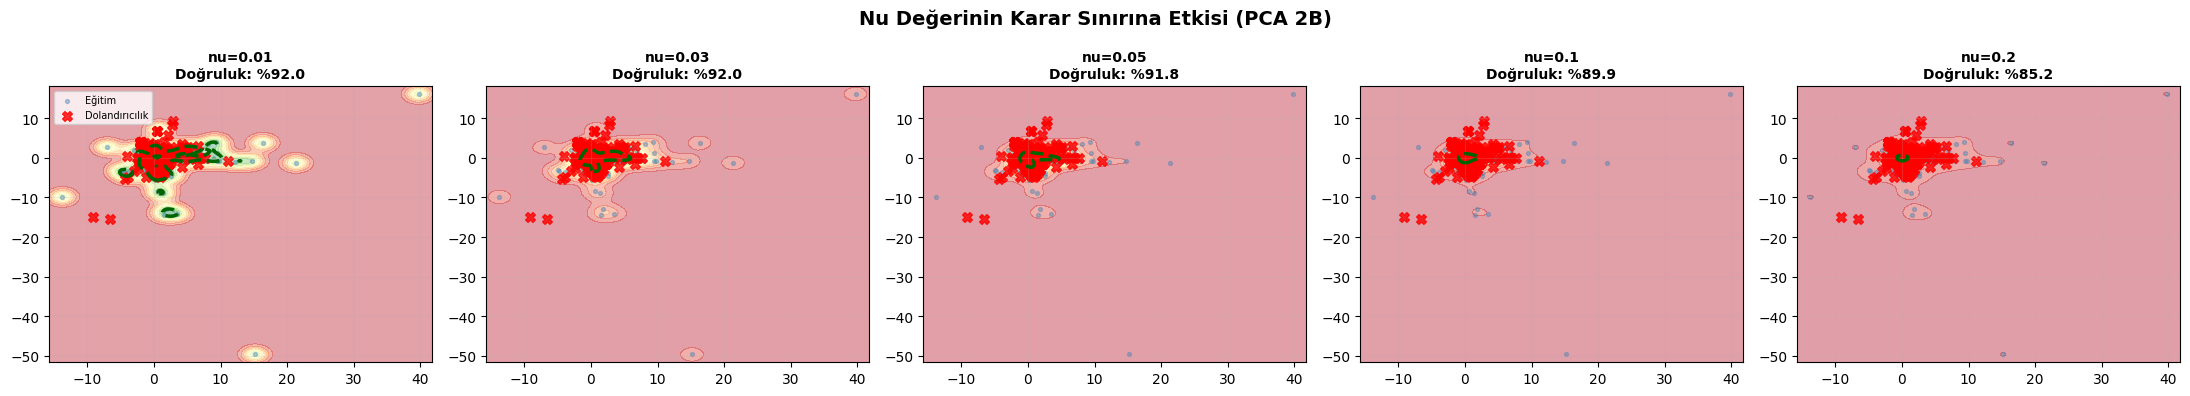

📸 Grafik kaydedildi: nu_karsilastirma.png


In [10]:
fig, axes = plt.subplots(1, len(nu_values), figsize=(22, 4))
fig.suptitle("Nu Değerinin Karar Sınırına Etkisi (PCA 2B)", fontsize=14, fontweight="bold")

for i, nu in enumerate(nu_values):
    ax = axes[i]

    m = OneClassSVM(kernel="rbf", nu=nu, gamma="scale")
    m.fit(X_train_pca)

    Z_nu = m.decision_function(grid_points).reshape(xx.shape)

    ax.contourf(xx, yy, Z_nu, levels=15, cmap="RdYlGn", alpha=0.4)

    ax.contour(xx, yy, Z_nu, levels=[0], linewidths=2.5,
               colors="darkgreen", linestyles="--")

    ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1],
               c="steelblue", s=8, alpha=0.4, label="Eğitim")

    fraud_pca_mask = y_test_true == -1
    ax.scatter(X_test_pca[fraud_pca_mask, 0], X_test_pca[fraud_pca_mask, 1],
               c="red", marker="X", s=50, alpha=0.8, label="Dolandırıcılık")

    acc = results[i]["Acc"]
    ax.set_title(f"nu={nu}\nDoğruluk: %{acc:.1f}", fontsize=10, fontweight="bold")
    ax.grid(True, alpha=0.2)
    if i == 0:
        ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("nu_karsilastirma.png", dpi=150, bbox_inches="tight")
plt.show()
print("📸 Grafik kaydedildi: nu_karsilastirma.png")

## 📋 11. Özet ve Sonuçlar

---

### 🎯 One-Class SVM'in Çalışma Mantığı

```
Eğitim:  Normal veri → [One-Class SVM] → Karar sınırı öğrenir
Test:    Yeni veri   → [Sınır içinde?] → Normal (+1) veya Dolandırıcılık (-1)
```

### ✅ Avantajlar
- Anormal veri **gerekmez** — gerçek hayatta çok değerli
- RBF çekirdeği sayesinde **doğrusal olmayan** sınırlar çizebilir
- `nu` ile anomali toleransı **ayarlanabilir**

### ⚠️ Sınırlamalar
- Yüksek boyutlu veride ve **büyük veri setlerinde** performans/hız düşer (bu yüzden örneklem alındı)
- `nu` ve `gamma` seçimi **deneyim gerektirir**
- Gerçek anomali oranı bilinmeden `nu` seçimi zor

### 🔧 Hiperparametre Rehberi
| Durum | Önerilen nu |
|-------|-------------|
| Anomali nadir (`<1%`) | 0.01 – 0.03 |
| Anomali az (`~5%`) | 0.05 – 0.10 |
| Anomali orta (`~15%`) | 0.10 – 0.20 |

In [11]:
print("=" * 50)
print("     ONE-CLASS SVM — SONUÇ ÖZETİ")
print("=" * 50)
print(f"  Veri seti      : Credit Card Fraud Detection")
print(f"  Eğitim seti    : {len(X_train)} normal işlem (örneklenmiş)")
print(f"  Test seti      : {len(X_test)} işlem ({len(test_normal)} normal + {len(fraud)} dolandırıcılık)")
print(f"  Kernel         : RBF")
print(f"  Nu (seçilen)   : {model.nu}")
print(f"  Genel Doğruluk : %{accuracy:.1f}")
print(f"  Tespit Edilen  : {TN}/{len(fraud)} dolandırıcılık (%{TN/len(fraud)*100:.0f})")
print("=" * 50)
print("\n✅ Notebook başarıyla tamamlandı!")

     ONE-CLASS SVM — SONUÇ ÖZETİ
  Veri seti      : Credit Card Fraud Detection
  Eğitim seti    : 3000 normal işlem (örneklenmiş)
  Test seti      : 1492 işlem (1000 normal + 492 dolandırıcılık)
  Kernel         : RBF
  Nu (seçilen)   : 0.05
  Genel Doğruluk : %91.8
  Tespit Edilen  : 436/492 dolandırıcılık (%89)

✅ Notebook başarıyla tamamlandı!
